# Indian Startup Funding EDA

## Objective
This project explores Indian startup funding data (2015-2020) to understand which cities lead in startup funding activity, and to practice handling real-world data quality issues — including encoding errors, inconsistent text formatting, and deliberately undisclosed values.

## Dataset
Source: Indian Startup Funding dataset (Kaggle), manually uploaded for practice with non-API data loading.

In [3]:
import os
print(os.listdir('/'))

['lib', 'mnt', 'proc', 'srv', 'opt', 'bin', 'var', 'boot', 'libx32', 'lib32', 'usr', 'tmp', 'run', 'etc', 'dev', 'home', 'media', 'lib64', 'sbin', 'root', 'sys', 'startup_funding.csv', 'kaggle', '.dockerenv', 'tools', 'datalab', 'content', 'python-apt', 'python-apt.tar.xz']


In [4]:
import pandas as pd
df  = pd.read_csv("/startup_funding.csv")

In [5]:
df.shape
df.head()


,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


In [6]:
df['Date dd/mm/yyyy'].dtype

dtype('O')

In [7]:
df['Date dd/mm/yyyy'] = pd.to_datetime(df['Date dd/mm/yyyy'], dayfirst=True , errors='coerce')


In [8]:
df['Date dd/mm/yyyy'].dtype

dtype('<M8[ns]')

In [9]:
df['Date dd/mm/yyyy'].isnull().sum()

np.int64(8)

In [10]:
df[df['Date dd/mm/yyyy'].isnull()]

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
192,193,NaT,Loan Tap,Consumer Internet,Online Lending Platform For Salaried Professio...,Mumbai,"Shunwei Capital, Tuscan Ventures, Ashish Goenk...",Private Equity,"62,50,000",NaN
2571,2572,NaT,HandyHome,Hyperlocal Electronics repair Service,NaN,Mumbai,"Bessemer Ventures, Kae Capital",Seed Funding,"6,30,000",NaN
2606,2607,NaT,\\xc2\\xa0Infinity Assurance,\\xc2\\xa0Warranty Programs Service Administra...,NaN,\\xc2\\xa0New Delhi,\\xc2\\xa0Indian Angel Network,Seed Funding,"\\xc2\\xa0600,000",NaN
2775,2776,NaT,Mobiefit,Mobile Fitness App,NaN,Goa,Prototyze,Seed Funding,NaN,NaN
2776,2777,NaT,Plancess,Online Education Platform,NaN,Mumbai,"Rajendra Gogri,\\xc2\\xa0 Chandrakant Gogri",Seed Funding,"20,00,000",NaN
2831,2832,NaT,The Porter,Logistics Tech,NaN,Mumbai,Kae Capital,Seed Funding,"5,00,000",NaN
3011,3012,NaT,Wishberry,NaN,NaN,NaN,"Rajan Anandan, Shankar Mahadevan, Deep Kalra &...",Seed Funding,"6,50,000",NaN
3029,3030,NaT,Corporate360,NaN,NaN,NaN,Group of Angel Investors,Seed Funding,"2,00,000",NaN


In [11]:
df =df.dropna(subset =['Date dd/mm/yyyy'])

In [12]:
df['Date dd/mm/yyyy'].isnull().sum()

np.int64(0)

In [13]:
df.shape

(3036, 10)

In [14]:
df['Amount in USD'].dtype

dtype('O')

In [15]:
df['Amount in USD'] = df['Amount in USD'].str.replace(',' , '')

In [16]:
df.head()

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,200000000,NaN
1,2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,8048394,NaN
2,3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,18358860,NaN
3,4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,3000000,NaN
4,5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,1800000,NaN


In [17]:
df['Amount in USD'] = pd.to_numeric(df['Amount in USD'] , errors='coerce' )

In [18]:
df['Amount in USD'].isnull().sum()

np.int64(977)

In [19]:
df[df['Amount in USD'].isnull()]

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
20,21,2019-11-17,Burger Singh,Food and Beverage,Indian Burger Brand,Gurgaon,RB Investments,Venture,NaN,NaN
34,35,2019-10-21,The Man Company,Consumer Goods,Beauty and Grooming,Gurgaon,Ayushmann Khurana,Corporate Round,NaN,NaN
58,59,2019-08-19,Mishry Reviews,Services,Product Review,Gurgaon,Vir Sanghvi,Series A,NaN,NaN
89,90,2019-05-06,Ola Electric,Transport,Cabs,Bengaluru,Tata Sons,Series A,NaN,NaN
91,92,2019-05-05,StyleDotMe,E-commerce,Fashion and Shopping,Delhi,Indian Angel Network and other angel investors...,Bridge Round,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
3027,3028,2015-05-21,Knit,NaN,NaN,NaN,"Rohit Jain, Amit Rambhia & Others",Seed Funding,NaN,NaN
3030,3031,2015-01-22,Freshmonk,NaN,NaN,NaN,"August Capital Partners, Michael Blakey",Seed Funding,NaN,NaN
3031,3032,2015-01-22,Englishleap.com,NaN,NaN,NaN,ANALEC,Private Equity,NaN,Majority Stake
3035,3036,2015-01-24,Impartus,NaN,NaN,NaN,Kaizen Private Equity,Private Equity,NaN,Series A


In [20]:
df.isnull().sum()

,0
Sr No,0
Date dd/mm/yyyy,0
Startup Name,0
Industry Vertical,169
SubVertical,929
City Location,178
Investors Name,24
InvestmentnType,4
Amount in USD,977
Remarks,2617


In [21]:
df = df.drop(columns=['Remarks'])

In [22]:
df.shape

(3036, 9)

In [23]:
df = df.dropna(subset = ['InvestmentnType'])

In [24]:
df.shape

(3032, 9)

In [25]:
df['Investors Name'] = df['Investors Name'].fillna('Unknown')

In [26]:
df.isnull().sum()

,0
Sr No,0
Date dd/mm/yyyy,0
Startup Name,0
Industry Vertical,169
SubVertical,929
City Location,178
Investors Name,0
InvestmentnType,0
Amount in USD,976


In [27]:
df['Industry Vertical'] = df['Industry Vertical'].fillna('Unknown')
df['City  Location'] = df['City  Location'].fillna('Unknown')

In [28]:
df = df.drop(columns= ['SubVertical'])

In [29]:
df.isnull().sum()

,0
Sr No,0
Date dd/mm/yyyy,0
Startup Name,0
Industry Vertical,0
City Location,0
Investors Name,0
InvestmentnType,0
Amount in USD,976


In [30]:
df.groupby('City  Location').size()

,0
City Location,
Agra,2
Ahemadabad,2
Ahemdabad,1
Ahmedabad,38
Amritsar,1
...,...
\\xc2\\xa0Bangalore,1
\\xc2\\xa0Gurgaon,4
\\xc2\\xa0Mumbai,1


In [33]:
df['City  Location'] = df['City  Location'].str.replace('\xc2\xa0', '')

In [34]:
df['City  Location'].unique()


array(['Bengaluru', 'Gurgaon', 'New Delhi', 'Mumbai', 'Chennai', 'Pune',
       'Noida', 'Faridabad', 'San Francisco', 'San Jose,', 'Amritsar',
       'Delhi', 'Kormangala', 'Hyderabad', 'Burnsville', 'Menlo Park',
       'Gurugram', 'Palo Alto', 'Santa Monica', 'Singapore', 'Taramani',
       'Andheri', 'Chembur', 'Haryana', 'New York', 'Karnataka',
       'Mumbai/Bengaluru', 'Bhopal', 'Bengaluru and Gurugram',
       'India/Singapore', 'Jaipur', 'India/US', 'Nagpur', 'Indore',
       'New York, Bengaluru', 'California', 'India', 'Ahemadabad',
       'Rourkela', 'Srinagar', 'Bhubneswar', 'Chandigarh',
       'Delhi & Cambridge', 'Kolkatta', 'Kolkata', 'Coimbatore',
       'Bangalore', 'Udaipur', 'Unknown', 'Ahemdabad', 'Bhubaneswar',
       'Ahmedabad', 'Surat', 'Goa', 'Uttar Pradesh', 'Nw Delhi', 'Gaya',
       'Vadodara', 'Trivandrum', 'Missourie', 'Panaji', 'Gwalior',
       'Karur', 'Udupi', 'Kochi', 'Agra', 'Bangalore/ Bangkok', 'Hubli',
       'Kerala', 'Kozhikode', 'US', 'Silig

In [35]:
df['City  Location'] = df['City  Location'].str.replace(r'\\xc2\\xa0', '', regex=True)

In [36]:
df['City  Location'].unique()


array(['Bengaluru', 'Gurgaon', 'New Delhi', 'Mumbai', 'Chennai', 'Pune',
       'Noida', 'Faridabad', 'San Francisco', 'San Jose,', 'Amritsar',
       'Delhi', 'Kormangala', 'Hyderabad', 'Burnsville', 'Menlo Park',
       'Gurugram', 'Palo Alto', 'Santa Monica', 'Singapore', 'Taramani',
       'Andheri', 'Chembur', 'Haryana', 'New York', 'Karnataka',
       'Mumbai/Bengaluru', 'Bhopal', 'Bengaluru and Gurugram',
       'India/Singapore', 'Jaipur', 'India/US', 'Nagpur', 'Indore',
       'New York, Bengaluru', 'California', 'India', 'Ahemadabad',
       'Rourkela', 'Srinagar', 'Bhubneswar', 'Chandigarh',
       'Delhi & Cambridge', 'Kolkatta', 'Kolkata', 'Coimbatore',
       'Bangalore', 'Udaipur', 'Unknown', 'Ahemdabad', 'Bhubaneswar',
       'Ahmedabad', 'Surat', 'Goa', 'Uttar Pradesh', 'Nw Delhi', 'Gaya',
       'Vadodara', 'Trivandrum', 'Missourie', 'Panaji', 'Gwalior',
       'Karur', 'Udupi', 'Kochi', 'Agra', 'Bangalore/ Bangkok', 'Hubli',
       'Kerala', 'Kozhikode', 'US', 'Silig

In [37]:
problem_values = df[df['City  Location'].str.contains('xc2', na=False)]['City  Location'].unique()
print(repr(problem_values))

array(['\\\\xc2\\\\xa0Noida', '\\\\xc2\\\\xa0Bangalore',
       '\\\\xc2\\\\xa0Gurgaon', '\\\\xc2\\\\xa0New Delhi',
       '\\\\xc2\\\\xa0Mumbai'], dtype=object)


In [38]:
df['City  Location'] = df['City  Location'].str.replace(r'\\\\xc2\\\\xa0', '', regex=True)

In [39]:
df['City  Location'].unique()

array(['Bengaluru', 'Gurgaon', 'New Delhi', 'Mumbai', 'Chennai', 'Pune',
       'Noida', 'Faridabad', 'San Francisco', 'San Jose,', 'Amritsar',
       'Delhi', 'Kormangala', 'Hyderabad', 'Burnsville', 'Menlo Park',
       'Gurugram', 'Palo Alto', 'Santa Monica', 'Singapore', 'Taramani',
       'Andheri', 'Chembur', 'Haryana', 'New York', 'Karnataka',
       'Mumbai/Bengaluru', 'Bhopal', 'Bengaluru and Gurugram',
       'India/Singapore', 'Jaipur', 'India/US', 'Nagpur', 'Indore',
       'New York, Bengaluru', 'California', 'India', 'Ahemadabad',
       'Rourkela', 'Srinagar', 'Bhubneswar', 'Chandigarh',
       'Delhi & Cambridge', 'Kolkatta', 'Kolkata', 'Coimbatore',
       'Bangalore', 'Udaipur', 'Unknown', 'Ahemdabad', 'Bhubaneswar',
       'Ahmedabad', 'Surat', 'Goa', 'Uttar Pradesh', 'Nw Delhi', 'Gaya',
       'Vadodara', 'Trivandrum', 'Missourie', 'Panaji', 'Gwalior',
       'Karur', 'Udupi', 'Kochi', 'Agra', 'Bangalore/ Bangkok', 'Hubli',
       'Kerala', 'Kozhikode', 'US', 'Silig

In [40]:
df.groupby('City  Location').size()

,0
City Location,
Agra,2
Ahemadabad,2
Ahemdabad,1
Ahmedabad,38
Amritsar,1
...,...
Udupi,2
Unknown,178
Uttar Pradesh,1


In [41]:
city_corrections = {
    'Ahemadabad': 'Ahmedabad',
    'Ahemdabad': 'Ahmedabad',
    'Kolkatta': 'Kolkata',
    'Bangalore': 'Bengaluru',
    'Gurgaon': 'Gurugram',
    'Nw Delhi': 'New Delhi'
}

df['City  Location'] = df['City  Location'].replace(city_corrections)

In [42]:
df['City  Location'].unique()

array(['Bengaluru', 'Gurugram', 'New Delhi', 'Mumbai', 'Chennai', 'Pune',
       'Noida', 'Faridabad', 'San Francisco', 'San Jose,', 'Amritsar',
       'Delhi', 'Kormangala', 'Hyderabad', 'Burnsville', 'Menlo Park',
       'Palo Alto', 'Santa Monica', 'Singapore', 'Taramani', 'Andheri',
       'Chembur', 'Haryana', 'New York', 'Karnataka', 'Mumbai/Bengaluru',
       'Bhopal', 'Bengaluru and Gurugram', 'India/Singapore', 'Jaipur',
       'India/US', 'Nagpur', 'Indore', 'New York, Bengaluru',
       'California', 'India', 'Ahmedabad', 'Rourkela', 'Srinagar',
       'Bhubneswar', 'Chandigarh', 'Delhi & Cambridge', 'Kolkata',
       'Coimbatore', 'Udaipur', 'Unknown', 'Bhubaneswar', 'Surat', 'Goa',
       'Uttar Pradesh', 'Gaya', 'Vadodara', 'Trivandrum', 'Missourie',
       'Panaji', 'Gwalior', 'Karur', 'Udupi', 'Kochi', 'Agra',
       'Bangalore/ Bangkok', 'Hubli', 'Kerala', 'Kozhikode', 'US',
       'Siliguri', 'USA', 'Lucknow', 'Kanpur', 'SFO / Bangalore',
       'London', 'Seattle / B

In [43]:
df['City  Location'].nunique()

100

In [45]:
top_cities = df.groupby('City  Location').size().sort_values(ascending=False).head(10)
print(top_cities)

City  Location
Bengaluru    842
Mumbai       563
New Delhi    424
Gurugram     340
Unknown      178
Pune         105
Hyderabad     99
Chennai       97
Noida         93
Ahmedabad     41
dtype: int64


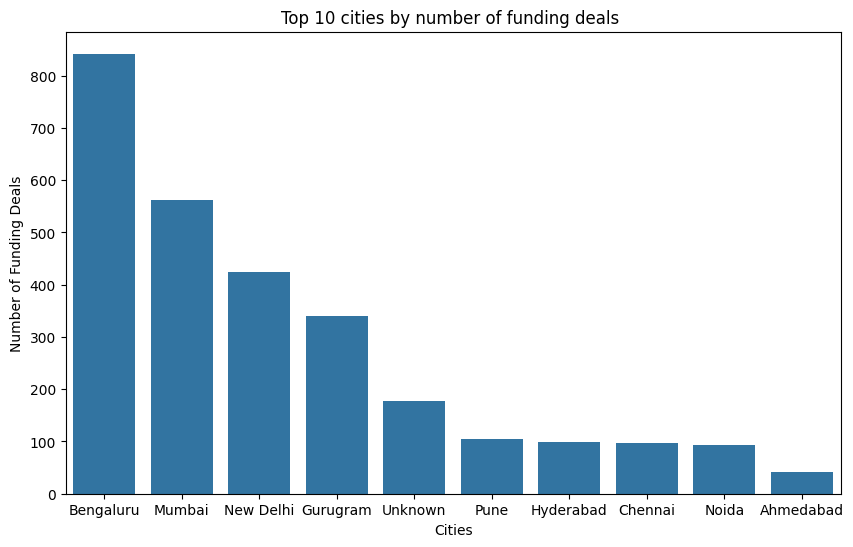

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize = (10,6))
sns.barplot(x=top_cities.index , y = top_cities.values)
plt.title("Top 10 cities by number of funding deals ")
plt.xlabel("Cities")
plt.ylabel("Number of Funding Deals")
plt.show()

In [49]:
df['Industry Vertical'].unique()

array(['E-Tech', 'Transportation', 'E-commerce', 'FinTech',
       'Fashion and Apparel', 'Logistics', 'Hospitality', 'Technology',
       'E-Commerce', 'Aerospace', 'B2B-focused foodtech startup',
       'Finance', 'Video', 'Gaming', 'Software', 'Health and wellness',
       'Education', 'Food and Beverage', 'Health and Wellness',
       'B2B Marketing', 'Video Games', 'SaaS', 'Last Mile Transportation',
       'Healthcare', 'Customer Service', 'B2B', 'Consumer Goods',
       'Advertising, Marketing', 'IoT', 'Information Technology',
       'Consumer Technology', 'Accounting', 'Retail',
       'Customer Service Platform', 'Automotive', 'EdTech', 'Services',
       'Compliance', 'Transport', 'Artificial Intelligence', 'Tech',
       'Health Care', 'Luxury Label', 'Waste Management Service',
       'Deep-Tech', 'Energy', 'Digital Media', 'Saas', 'Automobile',
       'Agtech', 'Social Media', 'Fintech', 'Edtech', 'AI', 'Ecommerce',
       'Nanotechnology', 'Services Platform', 'Travel Te

In [50]:
df['InvestmentnType'].unique()

array(['Private Equity Round', 'Series C', 'Series B', 'Pre-series A',
       'Seed Round', 'Series A', 'Series D', 'Seed', 'Series F',
       'Series E', 'Debt Funding', 'Series G', 'Series H', 'Venture',
       'Seed Funding', 'Funding Round', 'Corporate Round', 'Maiden Round',
       'pre-series A', 'Seed Funding Round', 'Single Venture',
       'Venture Round', 'Pre-Series A', 'Angel', 'Series J',
       'Angel Round', 'pre-Series A', 'Venture - Series Unknown',
       'Bridge Round', 'Private Equity', 'Debt and Preference capital',
       'Inhouse Funding', 'Seed/ Angel Funding', 'Debt', 'Pre Series A',
       'Equity', 'Debt-Funding', 'Mezzanine', 'Series B (Extension)',
       'Equity Based Funding', 'Private Funding', 'Seed / Angel Funding',
       'Seed/Angel Funding', 'Seed funding', 'Seed / Angle Funding',
       'Angel / Seed Funding', 'Private', 'Structured Debt', 'Term Loan',
       'PrivateEquity', 'Angel Funding', 'Seed\\\\nFunding',
       'Private\\\\nEquity', 'Crowd 

## Conclusion

**Key findings:**
- Bengaluru dominates Indian startup funding activity with 842 deals — more than double the next closest city (Mumbai, 563 deals)
- Delhi NCR region (New Delhi + Gurugram combined) shows strong concentration, rivaling Mumbai when considered together
- Nearly a third of recorded deals had no disclosed funding amount — a notable data limitation, not a data error

**Data quality challenges encountered and addressed:**
- Inconsistent date formats requiring explicit day-first parsing, with 8 unparseable entries dropped
- Currency values stored as text with comma formatting, requiring cleaning before numeric conversion
- City names affected by both encoding corruption (double-escaped characters) and spelling/naming inconsistencies (e.g., Bangalore/Bengaluru, Gurgaon/Gurugram) — standardized the most significant duplicates
- Industry Vertical column found to be too inconsistent (mixing broad categories with detailed business descriptions) to clean within scope — excluded from visual analysis as a noted limitation

**Tools used:** Python, Pandas, Matplotlib, Seaborn, Google Colab